## EX 1:  Mass-spring damper system


Let us consider a mass-spring-damper system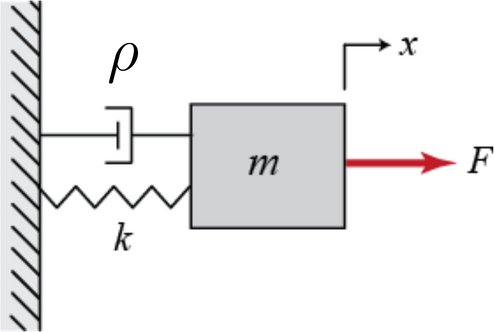

With the following system parameters:

      mass  m = 1.0 kg

      spring constant k = 5.0 N/m

      damping constant $\rho$ = 2 Ns/m

The state space model of the system is the following:

$$\dot x = Ax + Bu$$
$$ y = Cx$$

where
state vector $x = (p,v)$ (p - position, v - velocity), and state and control matrices are the following:
$$ A = \begin{pmatrix} 0&1\\ -\frac{k}{m}&-\frac{\rho}{m}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix}$$

## TODO
1. Is the system controllable?
2. Design a PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
3. Design a full-state feedback controller with an integral term $u = -Kx + k_z\int_0^t(y_{ref}(\tau) - p(\tau))\,d\tau$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly, to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
4. Compare the performance of PID and full-state feedback controllers. What can you say? 

Let us now work with a discretized version of the system.

5. Disretise the system with sampling time T = 0.1s
6. Design a discrete version of the PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
7. Design a full-state feedback controller with an integral term $u_k = - Kx_k + k_z\sum_{i=0}^k(y_{ref, i} - p_i)$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
8. Compare the performance of PID and full-state feedback controllers. What can you say?


In [138]:
# Verification if the system is controllable
import numpy as np
import control as ct

m = 1.0  # mass
k = 5.0  # spring constant
ro = 2.0  # damping coefficient

A = np.array([[0, 1], [-k / m, -ro / m]])
B = np.array([[0], [1 / m]])
C = np.array([[1, 0]])
D = np.array([[0]])


def is_controllable(A, B):
    n = A.shape[0]
    controllability_matrix = B
    for i in range(1, n):
        controllability_matrix = np.hstack(
            (controllability_matrix, np.linalg.matrix_power(A, i) @ B)
        )
    return np.linalg.matrix_rank(controllability_matrix) == n


print("Is the system controllable?", is_controllable(A, B))



Is the system controllable? True


zeta = 0.5912
wn = 3.3832
Plant G(s): <TransferFunction>: sys[400]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -4.441e-16 s + 1
  ----------------
   s^2 + 2 s + 5
Desired closed-loop poles: [(-1.9999999999999998+2.728752707683682j), (-1.9999999999999998-2.728752707683682j), np.float64(-9.999999999999998)]
Chosen extra pole p3 = -10.0000
PID gains: Kp=46.4461, Ki=114.4609, Kd=12.0000


/home/vizanca/.eng_env/lib/python3.12/site-packages/scipy/signal/_lti_conversion.py:76: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


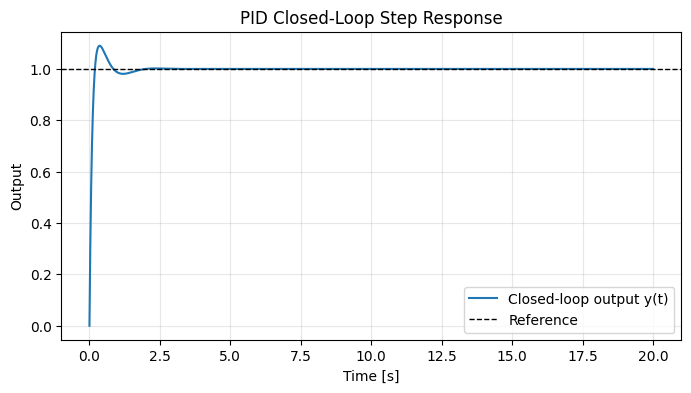

Rise time: 0.1376 s
Overshoot: 9.03 %
Steady-state error: 0.000000


In [142]:
import control as ct

# Performance requirements
rise_time_max = 10.0   # seconds
overshoot_max = 10.0   # percent
sse_max = 0.02         # 2%

# We choose a faster target than the maximum allowed rise time to avoid very weak gains
rise_time_target = 2.0
overshoot_target = 10.0

# 2nd-order approximation parameters from the targets
zeta = -np.log(overshoot_target / 100.0) / np.sqrt(np.pi**2 + np.log(overshoot_target / 100.0) ** 2)
wn = 4.0 / (zeta * rise_time_target)
sigma = zeta * wn
wd = wn * np.sqrt(1.0 - zeta**2)

print(f"zeta = {zeta:.4f}")
print(f"wn = {wn:.4f}")


# Rebuild EX1 plant explicitly (avoids overwritten A, B, C, D from other exercises)
A_ms = np.array([[0.0, 1.0],
                 [-5.0, -2.0]])
B_ms = np.array([[0.0],
                 [1.0]])
C_ms = np.array([[1.0, 0.0]])
D_ms = np.array([[0.0]])

G = ct.ss2tf(ct.ss(A_ms, B_ms, C_ms, D_ms))
print("Plant G(s):", G)

p1,p2 = complex(-sigma, wd), complex(-sigma, -wd)

# PID: C(s) = Kp + Ki/s + Kd*s
# Closed-loop characteristic polynomial with unity feedback:
# s^3 + (2 + Kd)s^2 + (5 + Kp)s + Ki
# Choose desired polynomial as dominant pair * extra real pole
p3 = 5.0 * sigma

poles_desired = [p1, p2, -p3]
print("Desired closed-loop poles:", poles_desired)

# (s^2 + 2*sigma*s + wn^2)*(s + p3) = s^3 + a2*s^2 + a1*s + a0
a2 = 2.0 * sigma + p3
a1 = wn**2 + 2.0 * sigma * p3
a0 = wn**2 * p3

Kd = a2 - 2.0
Kp = a1 - 5.0
Ki = a0

print(f"Chosen extra pole p3 = {-p3:.4f}")
print(f"PID gains: Kp={Kp:.4f}, Ki={Ki:.4f}, Kd={Kd:.4f}")

# Build PID and closed-loop transfer function
Cpid = ct.tf([Kd, Kp, Ki], [1, 0])
T = ct.feedback(Cpid * G, 1)

# Step response and metrics
t = np.linspace(0, 20, 2001)
t, y = ct.step_response(T, T=t)


# Optional plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(t, y, label="Closed-loop output y(t)")
plt.axhline(1.0, color="k", linestyle="--", linewidth=1, label="Reference")
plt.title("PID Closed-Loop Step Response")
plt.xlabel("Time [s]")
plt.ylabel("Output")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#Comando para calcular métricas de desempenho
# Compute performance metrics from step_info dictionary
info = ct.step_info(T)

tr = float(info["RiseTime"])
overshoot = float(info["Overshoot"])
sse = abs(1.0 - float(info["SteadyStateValue"]))

print(f"Rise time: {tr:.4f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {sse:.6f}")

Ganho K: [46.44609134 12.        ]
Ganho kz: 114.46091339690985


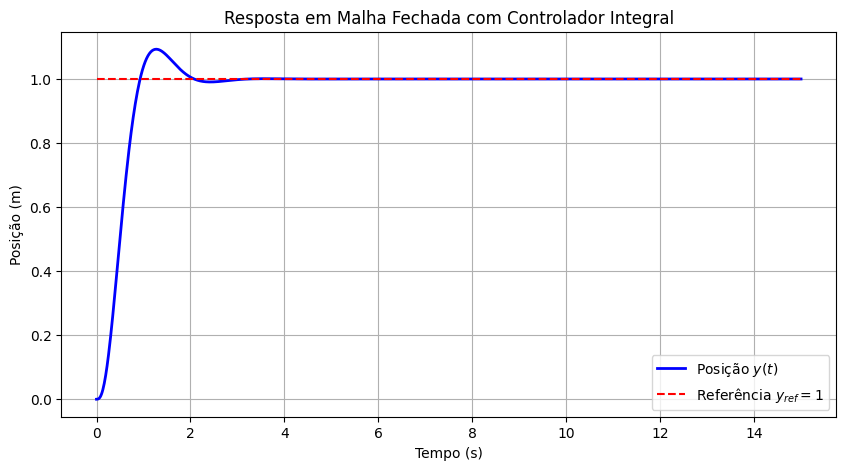

Rise time: 0.5803 s
Overshoot: 9.30 %
Steady-state error: 0.000000


In [143]:


# 2. Matrizes do Sistema Aumentado
# Aa = [ A   0 ]
#      [-C   0 ]
Aa = np.block([
    [A, np.zeros((2, 1))],
    [-C, np.zeros((1, 1))]
])

# Ba = [ B ]
#      [ 0 ]
Ba = np.block([
    [B],
    [np.zeros((1, 1))]
])

# 3. Alocação de Polos
# Polos desejados para atingir as restrições de tempo e sobressinal
p = poles_desired

# Calcula os ganhos K_a usando o método place
#Como se estivesse fazendo Ackermann, mas usando place para o sistema aumentado
# Formula Ackermann: K = [0 0 1] * inv(controllability_matrix) * desired_char_poly(A).
# polinomio característico desejado: (s+2)(s+3)(s+4) = s^3 + 9s^2 + 26s + 24
# Portanto A = A^3 + 9A^2 + 26A + 24I
# 
Ka = ct.place(Aa, Ba, p)

# Extrai os ganhos (lembrando que u = -Ka * x_a = -K*x - k3*z, e queremos + kz*z)
K = Ka[0, 0:2]
kz = -Ka[0, 2]

print(f"Ganho K: {K}")
print(f"Ganho kz: {kz}")

# 4. Simulação em Malha Fechada
# O sistema em malha fechada aumentado é x_a_dot = (Aa - Ba*Ka)*x_a + B_ref * y_ref
A_cl = Aa - Ba @ Ka

# A entrada de referência y_ref entra na derivada do integrador: z_dot = y_ref - y
B_cl = np.array([[0], 
                 [0], 
                 [1]])

# Queremos observar a posição, que é o primeiro estado x1
C_cl = np.array([[1, 0, 0]])
D_cl = np.array([[0]])

sys_cl = ct.StateSpace(A_cl, B_cl, C_cl, D_cl)

# Vetor de tempo (0 a 15 segundos) e referência (degrau unitário)
t = np.linspace(0, 15, 1000)
y_ref = np.ones_like(t)

# Simulando o sistema partindo de x = (0,0) e integrador = 0
t, y = ct.forced_response(sys_cl, T=t, U=y_ref, X0=[0, 0, 0])

# 5. Plotagem
plt.figure(figsize=(10, 5))
plt.plot(t, y, label='Posição $y(t)$', color='blue', linewidth=2)
plt.plot(t, y_ref, '--', label='Referência $y_{ref} = 1$', color='red')
plt.title('Resposta em Malha Fechada com Controlador Integral')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.grid(True)
plt.legend()
plt.show()

info = ct.step_info(sys_cl)
tr = float(info["RiseTime"])
overshoot = float(info["Overshoot"])
sse = abs(1.0 - float(info["SteadyStateValue"]))
print(f"Rise time: {tr:.4f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {sse:.6f}")

**Comparison of Continuous Controllers (Item 4):**

Both the Continuous PID and the Full-State Feedback with Integral Action (FSFB+I) controllers successfully achieve zero steady-state error ($e_{ss} = 0\%$), meeting the accuracy requirement.

*   **Continuous PID:** This controller provides an extremely fast response with a rise time of **0.1376 s**. The overshoot is **9.03%**, which satisfies the $<10\%$ constraint. The rapid rise time is characteristic of PID control where the added zeros (from the $K_d$ and $K_p$ terms) speed up the system response significantly.
*   **FSFB+I:** Using the same target poles, the state feedback controller results in a rise time of **0.5803 s** and an overshoot of **9.30%**. While slower than the PID, it behaves exactly as expected for the assigned 2nd-order dominant poles without the influence of additional zeros.

**Conclusion:** Both designs meet all performance criteria (Rise time < 10s, Overshoot < 10%, SSE < 2%). The PID is more aggressive (4x faster), while the FSFB follows the pole-placement design dynamics more strictly.

----------


### Discretized Control

In [139]:
Ts = 0.1  



# 2. Discretize the plant using Zero-Order Hold (ZOH)
sys_c = ct.StateSpace(A, B, C, D)
sys_d = ct.c2d(sys_c, Ts, method='zoh')
Ad = sys_d.A
Bd = sys_d.B
Cd = sys_d.C

# 3. Build the discrete augmented system
# Augmented state vector: [x1(k), x2(k), z(k)]^T
A_ad = np.block([
    [Ad, np.zeros((2, 1))],
    [-Ts * Cd, np.eye(1)]
])

B_ad = np.block([
    [Bd],
    [np.zeros((1, 1))]
])





--- Item 6 (Discrete PID) ---
Rise time: 0.700 s
Settling time: 1.400 s
Overshoot: 1.21 %
Steady-state error: 0.00001 (0.00%)

Criteria check:
Rise time < 10 s -> OK
Overshoot < 10% -> OK
Steady-state error < 2% -> OK


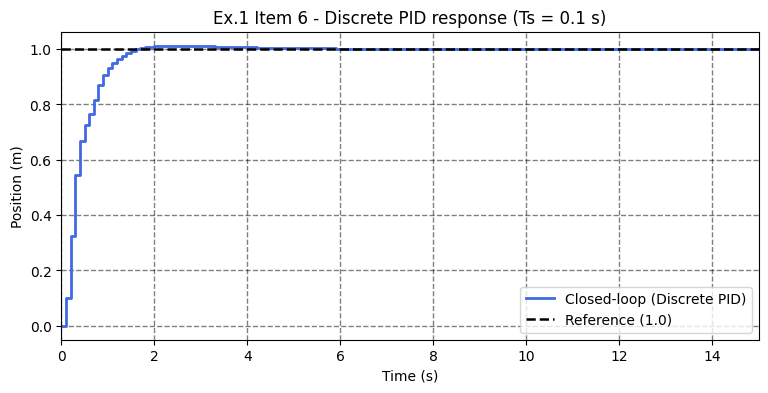

In [140]:
# Item 6 - Discrete PID controller (sampling time Ts = 0.1 s)
from scipy import signal
import control as ctr

Ts = 0.1
Ad, Bd, Cd, Dd, _ = signal.cont2discrete((A, B, C, D), Ts, method='zoh')

tf_d = 15.0
t_d = np.arange(0.0, tf_d + Ts, Ts)
N = len(t_d)

# Constant reference y_ref,k = 1
r_d = np.ones(N)

# PID gains (tuned)
Kp_d = 20.0
Ki_d = 12.0
Kd_d = 8.0

x_d = np.zeros(Ad.shape[0])
y_d = np.zeros(N)
u_d = np.zeros(N)

e_prev = 0.0
e_int = 0.0

for k in range(N):
    y_d[k] = (Cd @ x_d).item()
    e_k = r_d[k] - y_d[k]
    e_int += e_k * Ts
    e_der = (e_k - e_prev) / Ts if k > 0 else 0.0
    u_d[k] = Kp_d * e_k + Ki_d * e_int + Kd_d * e_der
    x_d = Ad @ x_d + Bd.flatten() * u_d[k]
    e_prev = e_k

info_d = ctr.step_info(y_d, T=t_d, final_output=1.0)
ess_d = abs(1.0 - y_d[-1])

print('--- Item 6 (Discrete PID) ---')
print(f'Rise time: {info_d["RiseTime"]:.3f} s')
print(f'Settling time: {info_d["SettlingTime"]:.3f} s')
print(f'Overshoot: {info_d["Overshoot"]:.2f} %')
print(f'Steady-state error: {ess_d:.5f} ({100*ess_d:.2f}%)')

print('\nCriteria check:')
print(f'Rise time < 10 s -> {"OK" if info_d["RiseTime"] < 10 else "NOK"}')
print(f'Overshoot < 10% -> {"OK" if info_d["Overshoot"] < 10 else "NOK"}')
print(f'Steady-state error < 2% -> {"OK" if ess_d < 0.02 else "NOK"}')

plt.figure(figsize=(9, 4))
plt.step(t_d, y_d, where='post', linewidth=2.0, color='royalblue', label='Closed-loop (Discrete PID)')
plt.step(t_d, r_d, where='post', linestyle='--', linewidth=1.8, color='black', label='Reference (1.0)')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.5)
plt.xlim([0, tf_d])
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Ex.1 Item 6 - Discrete PID response (Ts = 0.1 s)')
plt.legend()
plt.show()

Mapped Discrete Poles: [np.complex128(0.7884377057886531+0.2206491108669248j), np.complex128(0.7884377057886531-0.2206491108669248j), np.float64(0.3678794411714424)]
Discrete Gain K: [31.60521046  7.58170741]
Discrete Gain kz: 65.44391283959166


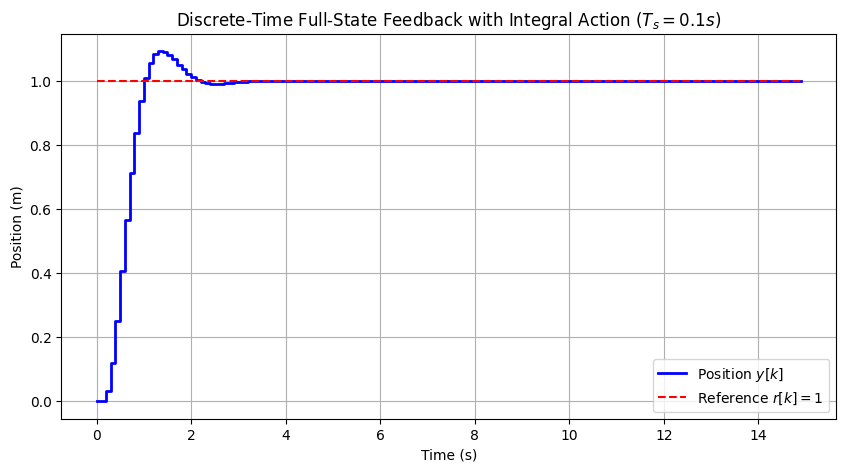

Rise time: 0.6000 s
Overshoot: 9.29 %
Steady-state error: 0.000000


In [141]:
#FeedBack control design using pole placement for the discrete augmented system
# 4. Map the continuous poles to the discrete domain (z = e^(s*Ts))
continuous_poles = poles_desired
discrete_poles = [np.exp(p * Ts) for p in continuous_poles]


# 5. Calculate the feedback gains using pole placement
Ka = ct.place(A_ad, B_ad, discrete_poles)

# Extract K and kz (Control law: u = -K*x + kz*z)
# The output from place gives u = -Ka * x_augmented = -K*x - (-kz)*z
K = Ka[0, 0:2]
kz = -Ka[0, 2] 

print(f"Mapped Discrete Poles: {discrete_poles}")
print(f"Discrete Gain K: {K}")
print(f"Discrete Gain kz: {kz}")

# 6. Simulate the system using a manual loop (Microcontroller logic)
t_sim = 15.0
n_steps = int(t_sim / Ts)
t = np.arange(0, n_steps * Ts, Ts)
r = np.ones_like(t)  # Unit step reference

# Initialize state and output arrays
x = np.zeros((2, 1)) # Plant states (position, velocity)
z = 0.0              # Integrator state
y = np.zeros(n_steps)
u = np.zeros(n_steps)

# The control loop running at every sample time Ts
for i in range(n_steps):
    # 6.1 Read the current output (sensor measurement)
    y[i] = (Cd @ x)[0, 0]
    
    # 6.2 Calculate the control action
    u_k = -K @ x + kz * z
    u[i] = u_k[0]
    
    # 6.3 Plant dynamics update (simulating physical physics for the next step)
    x_next = Ad @ x + Bd * u_k
    
    # 6.4 Integrator update using Forward Euler: z(k+1) = z(k) + Ts * error
    error = r[i] - y[i]
    z_next = z + Ts * error
    
    # 6.5 Update variables for the next iteration
    x = x_next
    z = z_next

# 7. Plotting the results
plt.figure(figsize=(10, 5))
plt.step(t, y, where='post', label='Position $y[k]$', color='blue', linewidth=2)
plt.plot(t, r, '--', label='Reference $r[k] = 1$', color='red')
plt.title('Discrete-Time Full-State Feedback with Integral Action ($T_s = 0.1s$)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.grid(True)
plt.legend()
plt.show()


#closed-loop system for step response analysis
A_cl = A_ad - B_ad @ Ka
B_cl = np.array([[0],
                 [0],
                 [Ts]])  # Reference input affects only the integrator state
C_cl = np.array([[1, 0, 0]])  # We want to observe the position output
D_cl = np.array([[0]])

sys_cl = ct.StateSpace(A_cl, B_cl, C_cl, D_cl, dt=Ts)
info = ct.step_info(sys_cl)
tr = float(info["RiseTime"])   
overshoot = float(info["Overshoot"])
sse = abs(1.0 - float(info["SteadyStateValue"]))
print(f"Rise time: {tr:.4f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {sse:.6f}")




Comparing the results for the discretized system ($T_s = 0.1s$):

*   **Discrete PID:** It is important to note that simply using the calculated poles with the sampling time of $T_s = 0.1s$ did not yield the expected behavior for the PID structure. Therefore, the **gains had to be empirically adjusted** to stabilize the response and meet the criteria. After this tuning, the controller acts conservatively but effectively, achieving a rise time of **0.700 s** and a very low overshoot of **1.21%**. The response is smooth and well-damped.
*   **Discrete FSFB+I:** The state feedback controller is more aggressive, resulting in a faster rise time of **0.600 s** (about 14% faster than the PID). However, this increase in speed leads to a significantly higher overshoot of **9.29%**, which is just within the 10% tolerance limit.

**Conclusion:** Both designs meet all performance criteria (Rise time < 10s, Overshoot < 10%, SSE < 2%). While the FSFB offers superior speed, the **Discrete PID** provides a better trade-off in this scenario, delivering a much smoother response with negligible overshoot, albeit requiring manual tuning to deal with the discretization effects.

## Ex 2. Quadruple-Tank Process

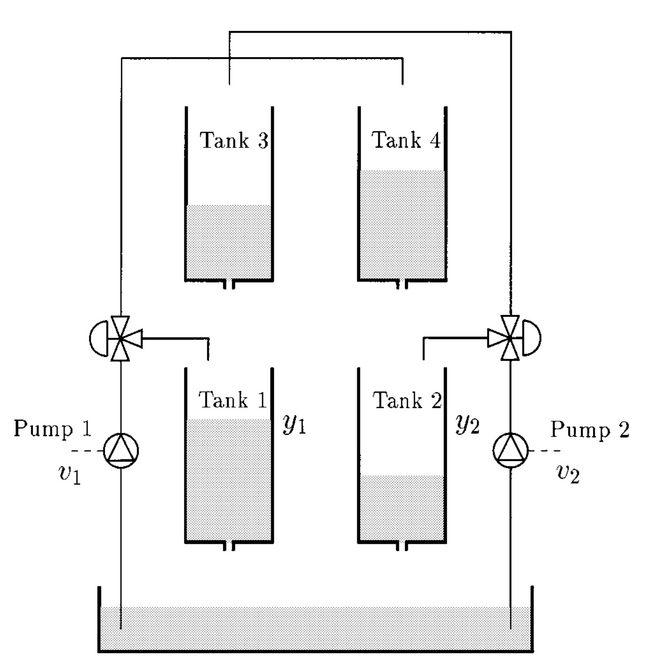

Let us consider the Quadruple-Tank Process. A schematic diagram of the process is shown in the Figure above. The
target is to control the level in the lower two tanks with two pumps. The process inputs are $v_1$ and $v_2$ (input voltages to the pumps) and the outputs are $y_1$ and $y_2$ (voltages from level measurement devices). Mass balances and Bernoulli’s law yield

$$
\dfrac{dh_1}{dt} = -\dfrac{a_1}{A_1}\sqrt{2gh_1} + \dfrac{a_3}{A_1}\sqrt{2gh_3} + \dfrac{\gamma_1k_1}{A_1}v_1 = f_1(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_2}{dt} = -\dfrac{a_2}{A_2}\sqrt{2gh_2} + \dfrac{a_4}{A_2}\sqrt{2gh_4} + \dfrac{\gamma_2k_2}{A_2}v_2 = f_2(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_3}{dt} = -\dfrac{a_3}{A_3}\sqrt{2gh_3} + \dfrac{(1-\gamma_2)k_2}{A_3}v_2 = f_3(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_4}{dt} = -\dfrac{a_4}{A_4}\sqrt{2gh_4} + \dfrac{(1-\gamma_1)k_1}{A_4}v_1 = f_4(h_1,h_2,h_3,h_4,v_1,v_2)
$$

where

$A_i$ is a cross-section of Tank i

$a_i$ is a cross-section of outlet hole of Tank i

$h_i$ is a water level.

The voltage applied to Pump $i$ is $v_i$ and the corresponding flow
is $k_iv_i$. The parameters $\gamma_1,\gamma_2\in (0,1)$ are determined from how the valves are set prior to experiment. The flow to Tank 1
is $\gamma_1k_1v_1$ and the flow to Tank 4 is $(1-\gamma_1)k_1v_1$ and similarly
for Tank 2 and Tank 3. The acceleration of gravity is denoted $g$.
The measured level signals are $k_c h_1$ and $k_c h_2$. The parameter
values of the laboratory process are given in the following table

    A_1, A_3 [cm^2] 28
    A_2, A_4 [cm^2] 32
    a_1, a_3 [cm^2] 0.071
    a_2, a_4 [cm^2] 0.057
    k_c [V/cm] 0.50
    g [cm/s^2] 9.81
    k_1 [cm^3/Vs] 3.33
    k_2 [cm^3/Vs] 3.35
    gamma_1 0.70
    gamma_2 0.60
    
Check the following paper for more details on the model. 
https://www.diva-portal.org/smash/get/diva2:495784/FULLTEXT01.pdf

## TODO
1. Linearise the system around the operating point 
$$(h_1^0,h_2^0,h_3^0,h_4^0, v_1^0, v_2^0) = (12.4,12.7,1.8,1.4,3.00,3.00).$$
Pass to shifted variables $x_i = h_i-h_i^0, u_i = v_i - v_i^0.$

2. Is the linear system controllable? Is the linear system observable? Use the Kalman rank test to answer this question.

3. Imagine that one of the pumps is broken and there is no flow through it. Does the system remain controllable?

4. Let us measure the signals $x_3, x_4$ instead of measuring the signals $x_1$ and $x_2,$ I .e matrix
   $$C= \begin{pmatrix} 0&0&1&0\\ 0&0&0&1 \end{pmatrix}$$
   instead of
   $$C= \begin{pmatrix} 1&0&0&0\\ 0&1&0&0 \end{pmatrix}.$$
 Is such a system observable?

In [ ]:
#Linearization 

#Linearizing around an operating point $$(h_1^0,h_2^0,h_3^0,h_4^0, v_1^0, v_2^0) = (12.4,12.7,1.8,1.4,3.00,3.00).$$ and introducing Dh_i = h_i-h_i^0 and Du_i = u_i-u_i^0, yield the linear equations: 

import numpy as np
import control as ct
import sympy as sp

#Linearization using jacobian matrices
h1, h2, h3, h4, v1, v2 = sp.symbols('h1 h2 h3 h4 v1 v2')
A1, A2, A3, A4, a1, a2, a3, a4 = sp.symbols('A1 A2 A3 A4 a1 a2 a3 a4')
gs, k1s, k2s, g1, g2 = sp.symbols('g k1 k2 gamma1 gamma2')
T1, T2, T3, T4 = sp.symbols('T1 T2 T3 T4')

x_sym = sp.Matrix([h1, h2, h3, h4])
u_sym = sp.Matrix([v1, v2])

f1 = -(a1/A1)*sp.sqrt(2*gs*h1) + (a3/A1)*sp.sqrt(2*gs*h3) + (g1*k1s/A1)*v1
f2 = -(a2/A2)*sp.sqrt(2*gs*h2) + (a4/A2)*sp.sqrt(2*gs*h4) + (g2*k2s/A2)*v2
f3 = -(a3/A3)*sp.sqrt(2*gs*h3) + ((1-g2)*k2s/A3)*v2
f4 = -(a4/A4)*sp.sqrt(2*gs*h4) + ((1-g1)*k1s/A4)*v1

f_sym = sp.Matrix([f1, f2, f3, f4])

jac_A_sym = f_sym.jacobian(x_sym)
jac_B_sym = f_sym.jacobian(u_sym)



#Operation point
h0 = np.array([12.4, 12.7, 1.8, 1.4])
v0 = np.array([3.0, 3.0])

#Parameters 
A_pts = np.array([28.0, 32.0, 28.0, 32.0])
a_pts= np.array([0.071, 0.057, 0.071, 0.057])
g = 9.81
k = [3.33, 3.35]
kc = 0.5
gamma = [0.7, 0.6]

#based on the article
#Calculation of Ti

# Ti = (Ai/ai) * sqrt(2*hi0 / g)
Ti = (np.array(A_pts) / np.array(a_pts)) * np.sqrt((2 * h0) / g)

print("--- Linears Equations---")
for i in range(4):
    eq_lin = 0
    # Parte Ax
    for j in range(4):
        if jac_A_sym[i,j] != 0:
            # Substituindo o termo derivado pela constante de tempo Ti para clareza
            term = jac_A_sym[i,j].subs(sp.sqrt(2*gs*x_sym[j]), (A_pts[j]*2*h0[j])/(a_pts[j]*Ti[j])) # Simplificação conceitual
            eq_lin += jac_A_sym[i,j] * sp.symbols(f'x{j+1}')
    
    # Parte Bu
    for j in range(2):
        if jac_B_sym[i,j] != 0:
            eq_lin += jac_B_sym[i,j] * sp.symbols(f'u{j+1}')
            
    print(f"dx{i+1}/dt = {sp.simplify(eq_lin)}")

    

 
#The linearized matrix are: 
# A represent how the tanks affect each other
# It shows how much water leaks from each tank, for example, the leak from tank 3 will increase the water in tank 1. Thats why in the first line
# we see a positive term for h3 in the equation of h1. The leak from tank 1 will decrease the water in tank 1, so we have a negative term for h1 in the first line.

A_lin = np.array([
    [-1/Ti[0], 0,          A_pts[2]/(A_pts[0]*Ti[2]), 0],
    [0,         -1/Ti[1], 0,                         A_pts[3]/(A_pts[1]*Ti[3])],
    [0,         0,         -1/Ti[2],                0],
    [0,         0,         0,                        -1/Ti[3]]
])


B_lin = np.array([
    [(gamma[0]*k[0])/A_pts[0], 0],
    [0,                        (gamma[1]*k[1])/A_pts[1]],
    [0,                        ((1-gamma[1])*k[1])/A_pts[2]],
    [((1-gamma[0])*k[0])/A_pts[3], 0]
])


# y = [kc 0 0 0; 0 kc 0 0] * x
C_lin = np.array([
    [kc, 0,  0, 0],
    [0,  kc, 0, 0]
])

# --- Results ---
print("Time Constants(T1, T2, T3, T4):")
print(Ti)
print("\nMatrix A:")
print(np.round(A_lin, 5))
print("\nMatrix B:")
print(np.round(B_lin, 5))

#Matrix Co (Contrability)
Co = ct.ctrb(A_lin, B_lin)
rank_Co = np.linalg.matrix_rank(Co)
print("\nMatrix of Controlability (Co):")
print(np.round(Co, 5))
print("\nControlability matrix rank:", rank_Co)

#Matrix Ob (Observability)
Ob = ct.obsv(A_lin, C_lin)
rank_Ob = np.linalg.matrix_rank(Ob)
print("\nMatrix of Observability (Ob):")
print(np.round(Ob, 5))
print("\nRank of Observability matrix:", rank_Ob)



if rank_Co == A_lin.shape[0]:
    print("\nThe system is controllable.")
else:
    print("\nThe system is not controllable.") 

if rank_Ob == A_lin.shape[0]:
    print("\nThe system is observable.")
else:
    print("\nThe system is not observable.")


 



--- Linears Equations---
dx1/dt = -sqrt(2)*a1*x1*sqrt(g*h1)/(2*A1*h1) + sqrt(2)*a3*x3*sqrt(g*h3)/(2*A1*h3) + gamma1*k1*u1/A1
dx2/dt = -sqrt(2)*a2*x2*sqrt(g*h2)/(2*A2*h2) + sqrt(2)*a4*x4*sqrt(g*h4)/(2*A2*h4) + gamma2*k2*u2/A2
dx3/dt = (-sqrt(2)*a3*x3*sqrt(g*h3)/2 - h3*k2*u2*(gamma2 - 1))/(A3*h3)
dx4/dt = (-sqrt(2)*a4*x4*sqrt(g*h4)/2 - h4*k1*u1*(gamma1 - 1))/(A4*h4)
Time Constants(T1, T2, T3, T4):
[627.03389734 903.35297108 238.90015379 299.92981154]

Matrix A:
[[-0.00159  0.       0.00419  0.     ]
 [ 0.      -0.00111  0.       0.00333]
 [ 0.       0.      -0.00419  0.     ]
 [ 0.       0.       0.      -0.00333]]

Matrix B:
[[0.08325 0.     ]
 [0.      0.06281]
 [0.      0.04786]
 [0.03122 0.     ]]

Matrix of Controlability (Co):
[[ 8.325e-02  0.000e+00 -1.300e-04  2.000e-04  0.000e+00 -0.000e+00
  -0.000e+00  0.000e+00]
 [ 0.000e+00  6.281e-02  1.000e-04 -7.000e-05 -0.000e+00  0.000e+00
   0.000e+00 -0.000e+00]
 [ 0.000e+00  4.786e-02  0.000e+00 -2.000e-04  0.000e+00  0.000e+00
   0.

In [20]:
# Simulate the scenario where pump 1 is broken (no flow through pump 1)
B_lin_pump1_broken = B_lin.copy()
B_lin_pump1_broken[:, 0] = 0  # Set the first column to zero

# Recompute controllability matrix and rank
Co_pump1_broken = ct.ctrb(A_lin, B_lin_pump1_broken)
rank_Co_pump1_broken = np.linalg.matrix_rank(Co_pump1_broken)

print("\nMatrix of Controllability (Co) with Pump 1 Broken:")
print(np.round(Co_pump1_broken, 5))
print("\nControlability matrix rank with Pump 1 Broken:", rank_Co_pump1_broken)

if rank_Co_pump1_broken == A_lin.shape[0]:
    print("\nThe system is controllable with Pump 1 broken.")
else:
    print("\nThe system is not controllable with Pump 1 broken.")

# Simulate the scenario where pump 2 is broken (no flow through pump 2)
B_lin_pump2_broken = B_lin.copy()
B_lin_pump2_broken[:, 1] = 0  # Set the second column to zero

# Recompute controllability matrix and rank
Co_pump2_broken = ct.ctrb(A_lin, B_lin_pump2_broken)
rank_Co_pump2_broken = np.linalg.matrix_rank(Co_pump2_broken)

print("\nMatrix of Controllability (Co) with Pump 2 Broken:")
print(np.round(Co_pump2_broken, 5))
print("\nControlability matrix rank with Pump 2 Broken:", rank_Co_pump2_broken)

if rank_Co_pump2_broken == A_lin.shape[0]:
    print("\nThe system is controllable with Pump 2 broken.")
else:
    print("\nThe system is not controllable with Pump 2 broken.")


Matrix of Controllability (Co) with Pump 1 Broken:
[[ 0.000e+00  0.000e+00  0.000e+00  2.000e-04  0.000e+00 -0.000e+00
   0.000e+00  0.000e+00]
 [ 0.000e+00  6.281e-02  0.000e+00 -7.000e-05  0.000e+00  0.000e+00
   0.000e+00 -0.000e+00]
 [ 0.000e+00  4.786e-02  0.000e+00 -2.000e-04  0.000e+00  0.000e+00
   0.000e+00 -0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00]]

Controlability matrix rank with Pump 1 Broken: 3

The system is not controllable with Pump 1 broken.

Matrix of Controllability (Co) with Pump 2 Broken:
[[ 0.08325  0.      -0.00013  0.       0.       0.      -0.       0.     ]
 [ 0.       0.       0.0001   0.      -0.       0.       0.       0.     ]
 [ 0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 0.03122  0.      -0.0001   0.       0.       0.      -0.       0.     ]]

Controlability matrix rank with Pump 2 Broken: 3

The system is not controllable with Pump 2 broken.


In [109]:

C_lin = np.array([
    [0, 0,  kc, 0],
    [0,  0, 0, kc]
])

#Matrix Ob (Observability)
Ob = ct.obsv(A_lin, C_lin)
rank_Ob = np.linalg.matrix_rank(Ob)
print("\nMatrix of Observability (Ob):")
print(np.round(Ob, 5))
print("\nRank of Observability matrix:", rank_Ob)

if rank_Ob == A_lin.shape[0]:
    print("\nThe system is observable.")
else:
    print("\nThe system is not observable.")




Matrix of Observability (Ob):
[[ 0.00e+00  0.00e+00  5.00e-01  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00  5.00e-01]
 [ 0.00e+00  0.00e+00 -2.09e-03  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00 -1.67e-03]
 [ 0.00e+00  0.00e+00  1.00e-05  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e-05]
 [ 0.00e+00  0.00e+00 -0.00e+00  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00 -0.00e+00]]

Rank of Observability matrix: 2

The system is not observable.


## EX3: Inverted Pendulum

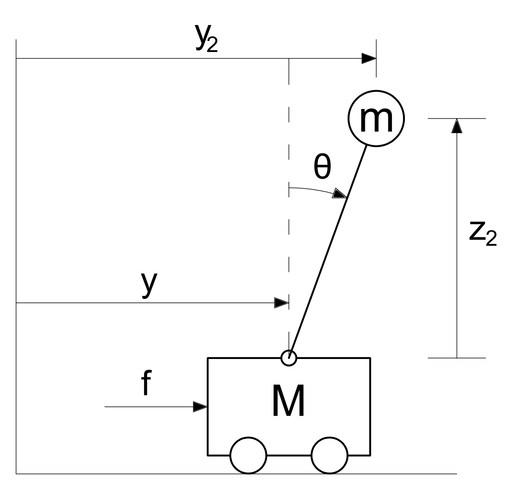
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.


Let us consider the system with the following system parameters

    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinate
    
    (theta)   angle between the pendulum and the vertical axis

## TODO

1) Show that the inverted pendulum on the cart can be modeled as follows

$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F$$

$$ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0$$

2) Let the state vector $x = (y,y_1,\theta,\theta_1),$ where $y_1 = \dot{y}$ and $\theta_1 = \dot{\theta}.$ Lineralize the system around equlibrium  point $x = (0,0,0,0).$

3) Is the autonomous system stable (u = 0)? Is the system controllable? Design a full state feedback controller $u = -Kx$ assigning the following eigenvalues $\lambda_1 = - 1, \lambda_2 = -2, \lambda_3 = -1.5, \lambda_4 = -2.5$ in the closed-loop system. Is a closed-loop system stable?

4) Let us assume that we only measure the position $y$ and the angular velocitity $\theta$. What is the right matrix C? Is the system observable?

5) Design an optimal estimator and an optimal estimated-state-feedback controller (both via LQR design as discussed in the lecture) which stabilize the system in (0,0,0,0).

6) Use the following library to implement an MPC controller
    https://github.com/forgi86/pyMPC/blob/master/README.md
   that stabilize the system while ensuring that following state and input constraints are satisfied

   $x_{min} = [-5,-100,-100,-100]\leq x \leq x_{max}= [5,100,100,100]$
   
   $u_{min} = -20 \leq u\leq u_{max}=20$
   
   The following notebook can be useful for you 
   https://github.com/forgi86/pyMPC/blob/master/examples/example_inverted_pendulum.ipynb
   

![WhatsApp Image 2026-03-18 at 22.50.24.jpeg](<attachment:WhatsApp Image 2026-03-18 at 22.50.24.jpeg>)

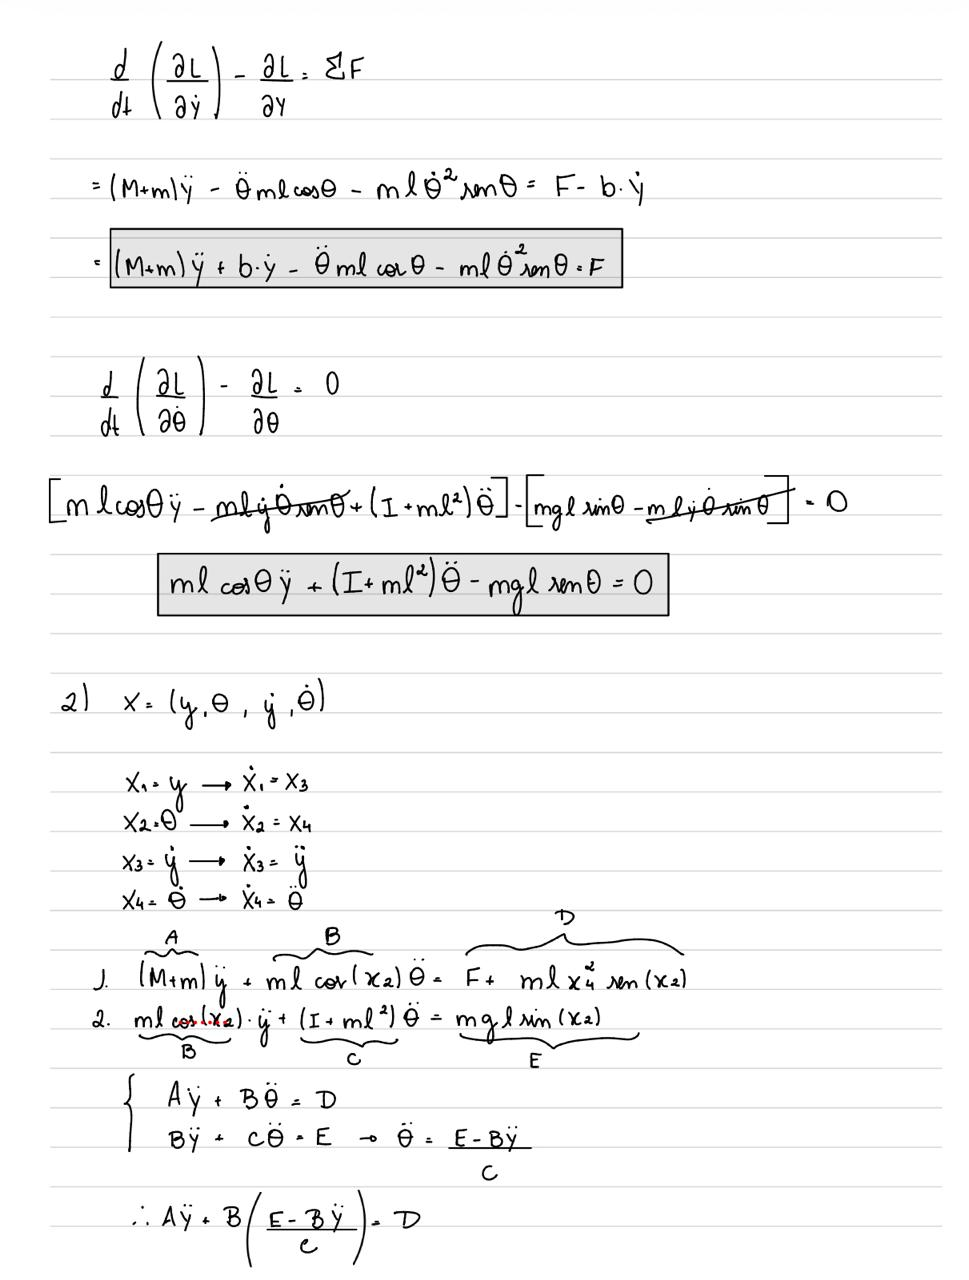

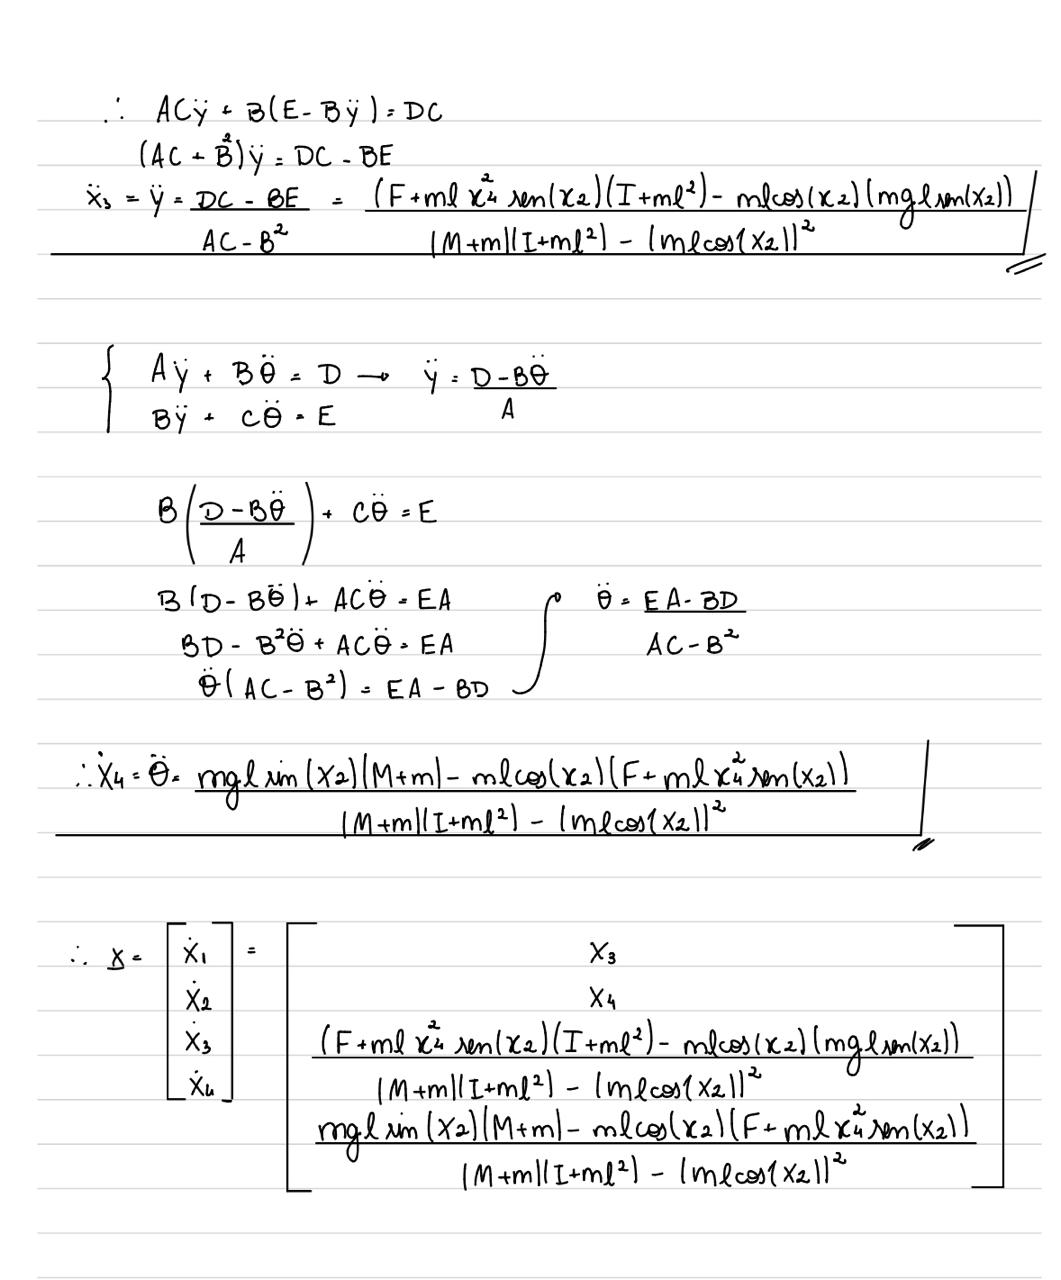
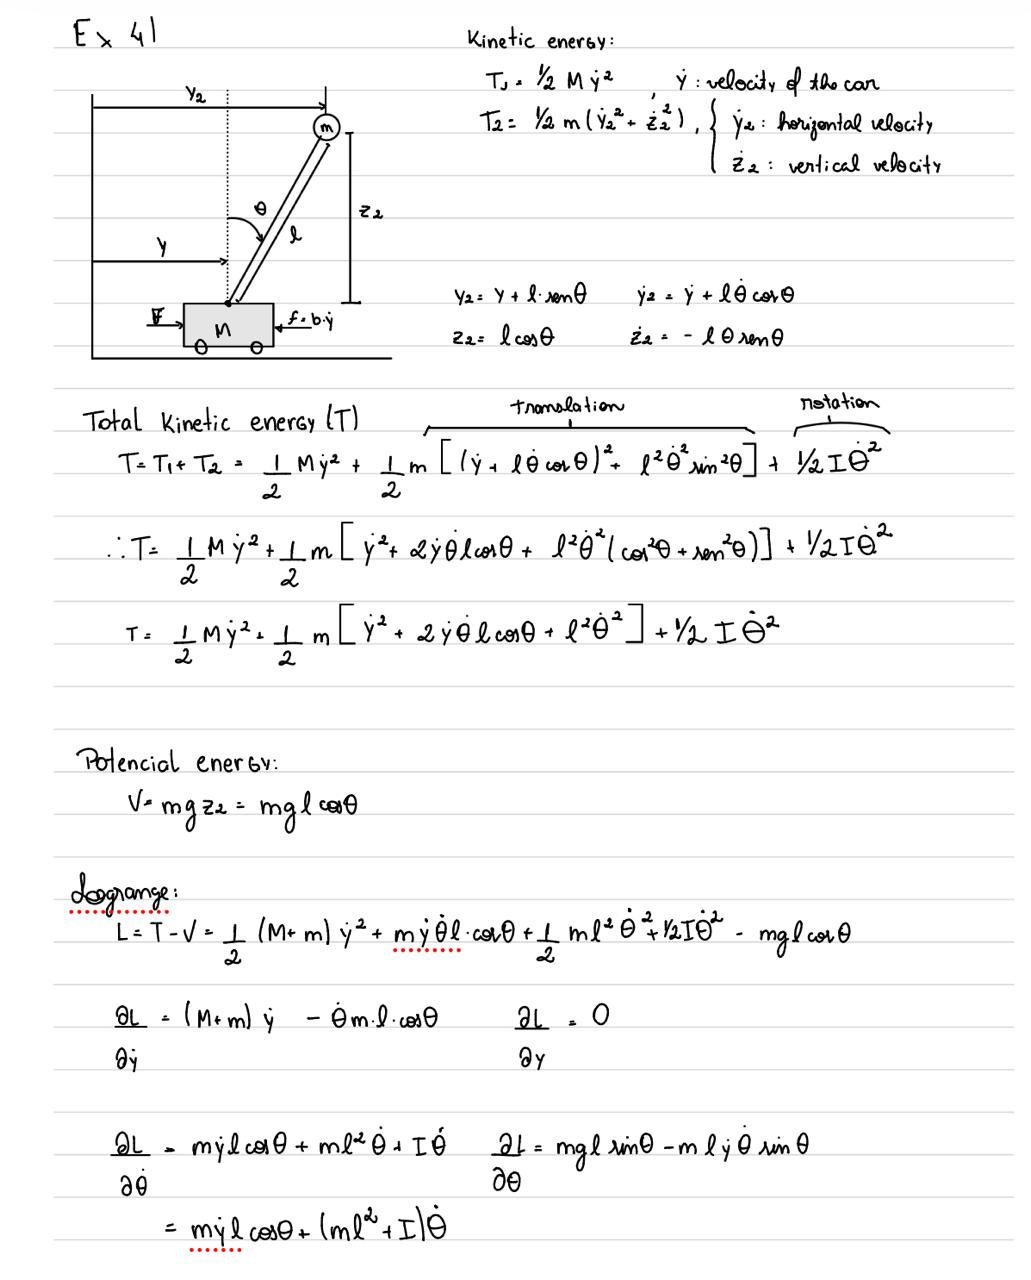

In [123]:
import sympy as sp
import numpy as np

# 2. Linearization

# Define symbols
y, theta, y_dot, theta_dot, F = sp.symbols('y theta y_dot theta_dot F')
M, m, l, b, I, g = sp.symbols('M m l b I g')

# System Matrices from equations of motion:
# Matrix Form: D(q) * q_ddot + C(q, q_dot) * q_dot + G(q) = H * u
# Here we solve directly for accelerations from the provided equations:
# Eq 1: (M+m)*y_ddot + m*l*cos(theta)*theta_ddot = F - b*y_dot + m*l*theta_dot^2*sin(theta)
# Eq 2: m*l*cos(theta)*y_ddot + (I+m*l^2)*theta_ddot = m*g*l*sin(theta)

# Mass Matrix D
D = sp.Matrix([
    [M + m, m * l * sp.cos(theta)],
    [m * l * sp.cos(theta), I + m * l**2]
])

# RHS (Force/Coriolis/Gravity terms moved to right side)
# We want D * [y_ddot; theta_ddot] = RHS
RHS = sp.Matrix([
    F - b * y_dot + m * l * theta_dot**2 * sp.sin(theta),
    m * g * l * sp.sin(theta)
])

# Solve for accelerations: [y_ddot; theta_ddot] = D_inv * RHS
accels = D.inv() @ RHS

y_ddot_expr = accels[0]
theta_ddot_expr = accels[1]

# State vector x = [y, y_dot, theta, theta_dot]
# f(x, u) = [y_dot, y_ddot, theta_dot, theta_ddot]
f = sp.Matrix([
    y_dot,
    y_ddot_expr,
    theta_dot,
    theta_ddot_expr
])

x = sp.Matrix([y, y_dot, theta, theta_dot])
u = sp.Matrix([F])

# Linearize around equilibrium x=0, u=0
# A = df/dx evaluated at 0
# B = df/du evaluated at 0
jac_A = f.jacobian(x)
jac_B = f.jacobian(u)

replacements = {y: 0, y_dot: 0, theta: 0, theta_dot: 0, F: 0}
A_lin_sym = jac_A.subs(replacements)
B_lin_sym = jac_B.subs(replacements)


# Numerical substitution
params = {
    M: 0.5,
    m: 0.2,
    l: 0.3,
    b: 0.1,
    I: 0.006,
    g: 9.81
}

A_lin_num = A_lin_sym.subs(params)
B_lin_num = B_lin_sym.subs(params)

# Convert to numpy arrays (type float)
A_sys = np.array(A_lin_num).astype(np.float64)
B_sys = np.array(B_lin_num).astype(np.float64)

print("\nNumerical A:")
print(A_sys)
print("\nNumerical B:")
print(B_sys)



Numerical A:
[[ 0.          1.          0.          0.        ]
 [ 0.         -0.18181818 -2.67545455  0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.          0.45454545 31.21363636  0.        ]]

Numerical B:
[[ 0.        ]
 [ 1.81818182]
 [ 0.        ]
 [-4.54545455]]


In [ ]:
import control as ct

# 3. Stability and Controllability Analysis

# 3.1 Autonomous system stability (u=0)
# The system is stable if all eigenvalues have negative real parts
eigenvalues_open_loop = np.linalg.eigvals(A_sys)
print("Open-loop Eigenvalues:")
print(eigenvalues_open_loop)

is_stable_open_loop = np.all(np.real(eigenvalues_open_loop) < 0)
if is_stable_open_loop:
    print("Result: The autonomous system is STABLE.")
else:
    print("Result: The autonomous system is UNSTABLE.")


# 3.2 Controllability
# Controllability matrix Co = [B AB A^2B ... A^(n-1)B]
Co = ct.ctrb(A_sys, B_sys)
rank_Co = np.linalg.matrix_rank(Co)
n_states = A_sys.shape[0]

print(f"\nControllability Matrix Rank: {rank_Co}")
if rank_Co == n_states:
    print("Result: The system is CONTROLLABLE.")
else:
    print("Result: The system is NOT CONTROLLABLE.")

# 3.3 Full State Feedback Controller Design
# Desired eigenvalues
desired_poles = [-1.0, -2.0, -1.5, -2.5]

# Calculate Gain K using pole placement
# PyControl's place function: K such that eigenvalues of (A - B*K) are desired_poles
K = ct.place(A_sys, B_sys, desired_poles)

print(f"\nCalculated Feedback Gain K: {K}")

# 3.4 Closed-loop Stability
# A_cl = A - B*K
A_cl = A_sys - B_sys @ K
eigenvalues_closed_loop = np.linalg.eigvals(A_cl) # Eigenvalues of the closed-loop system

print("\nClosed-loop Eigenvalues:")
print(eigenvalues_closed_loop)

is_stable_closed_loop = np.all(np.real(eigenvalues_closed_loop) < 0)
if is_stable_closed_loop:
    print("Result: The closed-loop system is STABLE.")
else:
    print("Result: The closed-loop system is UNSTABLE.")

Open-loop Eigenvalues:
[ 0.         -0.14283166 -5.60694213  5.56795561]
Result: The autonomous system is UNSTABLE.

Controllability Matrix Rank: 4
Result: The system is CONTROLLABLE.

Calculated Feedback Gain K: [[-0.16819572 -0.53170234 10.83927829  1.71268094]]

Closed-loop Eigenvalues:
[-2.5 -2.  -1.5 -1. ]
Result: The closed-loop system is STABLE.


In [124]:
# 4. Observability Analysis

# The problem states we measure position y and "angular velocitity theta". 
# "Theta" typically corresponds to the angle (state x3), while "velocity" would be x4.
# Given the symbol used is theta, we construct C assuming we measure y and theta (angle).

# State vector x = [y, y_dot, theta, theta_dot]
# Output vector y_out = [y, theta]

C = np.array([
    [1, 0, 0, 0],  # Selects y (1st state)
    [0, 0, 1, 0]   # Selects theta (3rd state)
])

print("Matrix C:")
print(C)

# Check Observability
# Observability matrix Ob = [C; CA; CA^2; CA^3]
Ob = ct.obsv(A_sys, C)
rank_Ob = np.linalg.matrix_rank(Ob)
n_states = A_sys.shape[0]

print(f"\nObservability Matrix Rank: {rank_Ob}")
if rank_Ob == n_states:
    print("Result: The system is OBSERVABLE.")
else:
    print("Result: The system is NOT OBSERVABLE.")

Matrix C:
[[1 0 0 0]
 [0 0 1 0]]

Observability Matrix Rank: 4
Result: The system is OBSERVABLE.


Step 1: LQR Gain K calculated.
[[-100.          -81.09610854 -323.74763835  -47.91780426]]

Step 2: LQE Gain L calculated.
[[ 0.7318878  -0.14489898]
 [ 0.22832774 -0.93676715]
 [-0.02904705  2.04840654]
 [-0.14489898 11.2740335 ]]

Step 3: Verification of Separation Principle:
Controller Poles: [-43.41601522+0.j         -23.9282143 +0.j
  -1.59915987+1.31717434j  -1.59915987-1.31717434j]
Observer Poles: [-0.43649312+0.36056993j -0.43649312-0.36056993j -5.65737662+0.85805624j
 -5.65737662-0.85805624j]


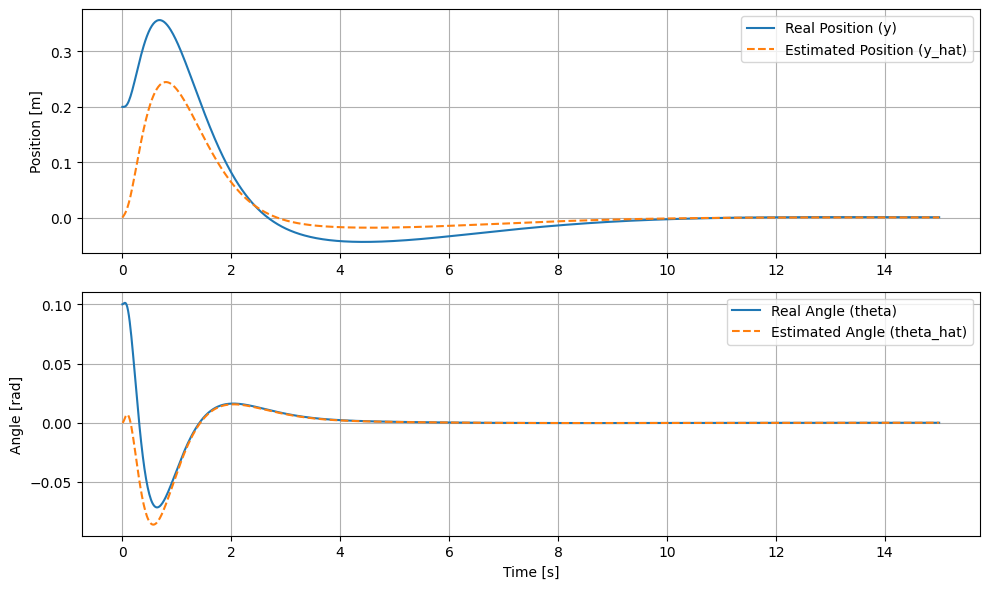

In [ ]:
# Measuring position y and ang. velocity theta_dot (as per item 4)


Q_lqr = np.diag([100, 1, 500, 1]) 

R_lqr = np.array([[0.01]])

# K is the optimal feedback gain: u = -Kx (Slide 112)
K_lqr, _, _ = ct.lqr(A_sys, B_sys, Q_lqr, R_lqr)
print(f"Step 1: LQR Gain K calculated.\n{K_lqr}")


Q_est = np.eye(4) * 0.01 # State estimation error penalty 
R_est = np.eye(2) * 0.1 # Measurement noise penalty (since we measure y and theta, we have 2 outputs)

# L is the optimal output injection matrix
L_transposed, _, _ = ct.lqr(A_sys.T, C.T, Q_est, R_est)
L_lqe = L_transposed.T
print(f"\nStep 2: LQE Gain L calculated.\n{L_lqe}")


A_comp = A_sys - (L_lqe @ C) - (B_sys @ K_lqr) # Observer dynamics: A - LC - BK 


A_total = np.block([
    [A_sys, -B_sys @ K_lqr],
    [L_lqe @ C, A_comp]
]) # Combined system matrix for the observer-based controller 


# Separation Principle check: Combined eigenvalues 
ctrl_poles = np.linalg.eigvals(A_sys - B_sys @ K_lqr)
obs_poles = np.linalg.eigvals(A_sys - L_lqe @ C)
print(f"\nStep 3: Verification of Separation Principle:")
print(f"Controller Poles: {ctrl_poles}")
print(f"Observer Poles: {obs_poles}")

sys_lqg = ct.ss(A_total, np.zeros((8, 1)), np.eye(8), 0) # We will simulate the full state and observer states, so C = I for plotting
time = np.linspace(0, 15, 1000)
# Initial condition: Cart offset by 0.2m, Pendulum offset by 0.1rad
x0 = [0.2, 0, 0.1, 0, 0, 0, 0, 0] 

t, y_out = ct.initial_response(sys_lqg, time, x0)

# --- STEP 5: Plotting ---
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y_out[0], label='Real Position (y)')
plt.plot(t, y_out[4], '--', label='Estimated Position (y_hat)')
plt.ylabel('Position [m]')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y_out[2], label='Real Angle (theta)')
plt.plot(t, y_out[6], '--', label='Estimated Angle (theta_hat)')
plt.ylabel('Angle [rad]')
plt.xlabel('Time [s]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Starting MPC Simulation...
Simulation Finished.


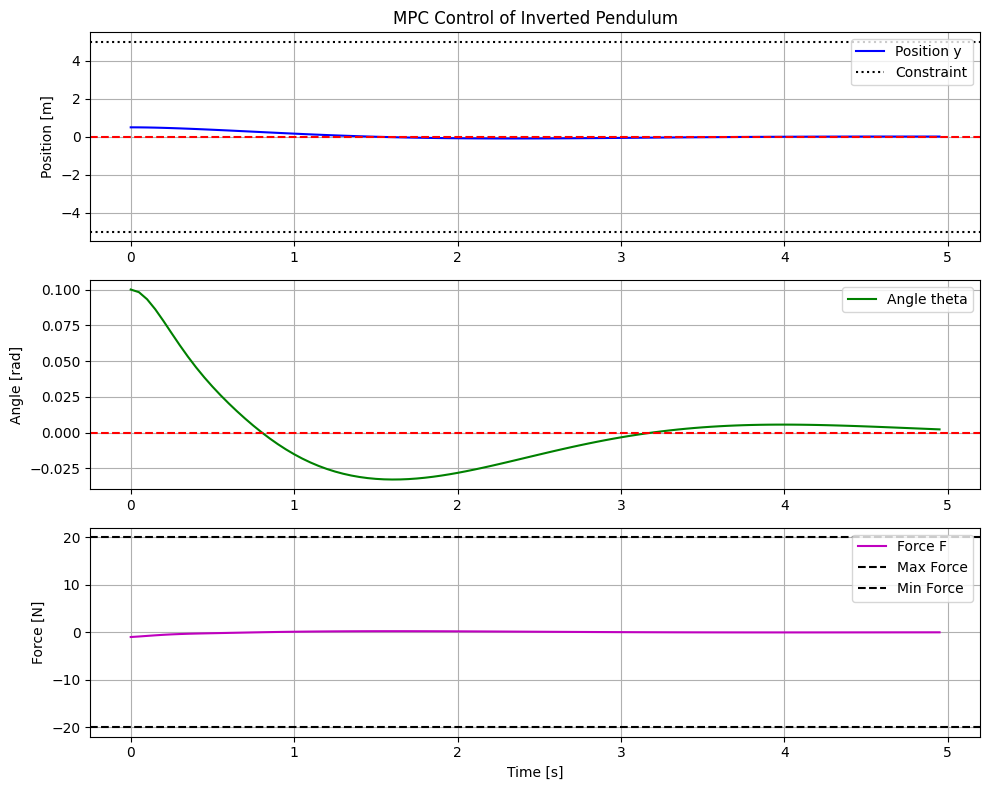

In [119]:
# 6. MPC Controller using pyMPC
import sys
import os

# Add pyMPC to path (assuming it was cloned in the workspace root or similar)
# Adjust path as necessary based on where it was cloned.
# Current cwd is /home/vizanca/Control/
sys.path.append('/home/vizanca/Control/pyMPC')

from pyMPC.mpc import MPCController
import scipy.sparse as sparse

# 6.1 Discretize the Inverted Pendulum System
Ts_mpc = 0.05  # Sampling time for MPC (usually faster than 0.1 for penulum)

# Discretize continuous A_sys, B_sys
# x(k+1) = Ad*x(k) + Bd*u(k)
sys_c_pendulum = ct.ss(A_sys, B_sys, C, 0)
sys_d_pendulum = ct.c2d(sys_c_pendulum, Ts_mpc, method='zoh')
Ad = sys_d_pendulum.A
Bd = sys_d_pendulum.B

[nx, nu] = Bd.shape

# 6.2 MPC Setup

# Reference: Stabilize to origin
xref = np.zeros(nx)
uref = np.zeros(nu)

# Constraints
# x = [y, y_dot, theta, theta_dot]
xmin = np.array([-5.0, -100.0, -100.0, -100.0])
xmax = np.array([ 5.0,  100.0,  100.0,  100.0])

umin = np.array([-20.0])
umax = np.array([ 20.0])

# Input Rate constraints (Optional / relaxed)
Dumin = np.array([-100.0])  # Relaxed
Dumax = np.array([ 100.0])

# Weights
# Penalize position (x0) and Angle (x2)
Qx = sparse.diags([10.0, 0.1, 100.0, 0.1])
QxN = sparse.diags([10.0, 0.1, 100.0, 0.1]) # Terminal cost
Qu = 0.1 * sparse.eye(nu)                  # Control effort cost
QDu = 0.01 * sparse.eye(nu)                # Control rate cost

# Prediction Horizon
Np = 20

# Initial State (Perturbed)
x0_mpc = np.array([0.5, 0.0, 0.1, 0.0]) # 0.5m displacement, 0.1 rad angle

# Instantiate Controller
# Note: uminus1 is previous input, usually 0 at start
mpc = MPCController(Ad, Bd, Np=Np, x0=x0_mpc, xref=xref, uminus1=np.zeros(nu),
                    Qx=Qx, QxN=QxN, Qu=Qu, QDu=QDu,
                    xmin=xmin, xmax=xmax, umin=umin, umax=umax, Dumin=Dumin, Dumax=Dumax)
mpc.setup()


# 6.3 Simulation Loop
t_final = 5.0
n_steps = int(t_final / Ts_mpc)
t_vec = np.arange(n_steps) * Ts_mpc

x_history = np.zeros((n_steps, nx))
u_history = np.zeros((n_steps, nu))

x_curr = x0_mpc
u_prev = np.zeros(nu)

print("Starting MPC Simulation...")
for k in range(n_steps):
    x_history[k, :] = x_curr
    
    # Update MPC with current state
    mpc.update(x_curr, u_prev)
    
    # Compute optimal control
    u_opt = mpc.output()
    u_history[k, :] = u_opt
    
    # Apply to plant (Simulation)
    # Using linear discrete model for simulation
    x_next = Ad @ x_curr + Bd @ u_opt
    
    x_curr = x_next
    u_prev = u_opt

print("Simulation Finished.")


# 6.4 Plotting Results
plt.figure(figsize=(10, 8))

# Position
plt.subplot(3, 1, 1)
plt.plot(t_vec, x_history[:, 0], 'b', label='Position y')
plt.axhline(0, color='r', linestyle='--')
plt.axhline(xmax[0], color='k', linestyle=':', label='Constraint')
plt.axhline(xmin[0], color='k', linestyle=':')
plt.ylabel('Position [m]')
plt.grid(True)
plt.legend()
plt.title('MPC Control of Inverted Pendulum')

# Angle
plt.subplot(3, 1, 2)
plt.plot(t_vec, x_history[:, 2], 'g', label='Angle theta')
plt.axhline(0, color='r', linestyle='--')
plt.ylabel('Angle [rad]')
plt.grid(True)
plt.legend()

# Control Input
plt.subplot(3, 1, 3)
plt.plot(t_vec, u_history[:, 0], 'm', label='Force F')
plt.axhline(umax[0], color='k', linestyle='--', label='Max Force')
plt.axhline(umin[0], color='k', linestyle='--', label='Min Force')
plt.ylabel('Force [N]')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()